<h1><center>Практическое задание по дисциплине</center></h1>
<h1><center>«Теория принятия решений»</center></h1>
<h1><center>Вариант 76</center></h1>
<h1><center>Порофиев Е.А. группа 3375</center></h1>

## Задание №3.

### Постановка задачи
В задаче необходимо определить распределение рабочих, занимающихся добычей минералов, с учетом нескольких возможных сценариев развития событий.
У игрока есть две базы – Б1 (главная) и Б2 (вспомогательная, построенная недавно). На главной базе находится 8 источников минералов, на вспомогательной - 6. Всего у игрока 20
юнитов, которые могут вести добычу минералов («рабочих»), и 1000 минералов в запасе. Производство одного рабочего занимает 12 секунд и стоит 50 минералов (в упрощенной постановке
можно считать, что юниты, произведенные до атаки, не назначаются на добычу, а остаются в резерве – простаивают). Противник готовит атаку. Если атака будет на главную базу, часть рабочих, занятых добычей минералов на главной базе, погибнет. Если атака будет на вспомогательную базу, то погибнут все рабочие, осуществляющие добычу там (вспомогательная база защищена гораз-
до хуже). Необходимо решить, сколько рабочих следует держать на каждой базе и сколько оставить в резерве (простаивать), чтобы потом, после атаки, перераспределить выживших.

На основании имеющихся сведений можно выделить следующие сценарии:
 - Сценарий А ($50%$): Атака на главную базу. Погибнет 60% рабочих, занятых добычей на главной базе.
 - Сценарий Б ($50%$): Атака на вспомогательную базу. Погибнут все рабочие на этой базе.
    
Атака произойдет через 60 секунд. После атаки будет еще 120 секунд до решающей битвы, в течение которых игрок будет добывать ресурсы выжившими рабочими. Каждый рабочий добывает 1 минерал в секунду (упрощение), на базе может работать не более 2 рабочих на источник минералов, лишние простаивают. Считается, что в начальный момент времени все рабочие находятся на основной базе.
Необходимо найти план действий (распределение и производство), максимизирующий количество минералов. Запишите полную задачу линейного программирования с двумя сценариями в виде детерминированного эквивалента. Найдите оптимальное решение.

Проанализируйте полученное решение:
1. Приведите сведения об эффективности полученного решения в каждом из возможных сценариев.
2. Сравните оптимальное решение с эвристической стратегией «поровну на обе базы, резерва нет, новых после атаки не производим». Выигрывает ли найденная оптимальная стратегия?
3. Как изменится решение, если вероятность атаки на главную базу не $50/50$, а $80/20$?

## Математическая постановка задачи
### Переменные решения

Задача решается в два этапа (до и после реализации неопределённости), но формулируется как единая задача стохастического программирования с рекурсией.

#### Переменные первого этапа:

$x_1 \in {0, 1, \dots, 16}$ — количество рабочих, назначенных на добычу на главной базе Б1;

$x_2 \in {0, 1, \dots, 12}$ — количество рабочих, назначенных на добычу на вспомогательной базе Б2;

$r \ge 0$ — количество рабочих, оставленных в резерве (простаивают);

$p \ge 0$ — количество дополнительных рабочих, произведённых до атаки.

#### Переменные второго этапа:

$y_A \ge 0$ — количество рабочих, осуществляющих добычу после атаки в сценарии А;

$y_B \ge 0$ — количество рабочих, осуществляющих добычу после атаки в сценарии Б.

Все переменные — целые неотрицательные.

### Ограничения и динамика

#### Начальные условия:

Начальное количество рабочих: $W_0 = 20$.

Начальный запас минералов: $M_0 = 1000$.

Все рабочие изначально не назначены на добычу.

#### Первый этап (до атаки, длительность $t_1 = 60$ с):

Баланс рабочих: $x_1 + x_2 + r = W_0 + p = 20 + p$.

Ограничение по числу слотов для добычи:

$x_1 \le 8 \times 2 = 16$ (8 источников по 2 рабочих);

$x_2 \le 6 \times 2 = 12$ (6 источников по 2 рабочих).

Добыча минералов до атаки: $M_{before} = t_1 \cdot (x_1 + x_2) = 60(x_1 + x_2)$.

Затраты на производство: $C = 50 \cdot p$ (производство одного рабочего занимает 12 с, но в данной упрощённой постановке временное ограничение на производство не учитывается, производится мгновенно в начале этапа).

После добычи и затрат запас минералов к моменту атаки:
$M_{attack} = M_0 + M_{before} - C = 1000 + 60(x_1 + x_2) - 50p$.

#### Второй этап (после атаки, длительность $t_2 = 120$ с):

Происходит атака по одному из двух сценариев.

Сценарий А (вероятность $P_A$): атака на главную базу Б1. Погибает 60% рабочих, занятых добычей на Б1. Выжившие рабочие:
$W_{surv}^A = W_0 + p - 0.6 x_1 = 20 + p - 0.6 x_1$.

Сценарий Б (вероятность $P_B = 1 - P_A$): атака на вспомогательную базу Б2. Погибают все рабочие, занятые добычей на Б2. Выжившие рабочие:
$W_{surv}^B = W_0 + p - x_2 = 20 + p - x_2$.

После атаки выжившие рабочие могут быть перераспределены между базами. Общее количество слотов для добычи на обеих базах составляет $16 + 12 = 28$. Следовательно, количество рабочих, реально осуществляющих добычу после атаки, не может превышать 28:

$y_A \le \min{W_{surv}^A, 28},\quad y_B \le \min{W_{surv}^B, 28}$.

Добыча после атаки для сценария $\omega \in {A, B}$:
$M_{after}^\omega = t_2 \cdot y_\omega = 120 \cdot y_\omega$.

Итоговое количество минералов для каждого сценария:
$M_{total}^\omega = M_{attack} + M_{after}^\omega = 1000 + 60(x_1 + x_2) - 50p + 120 y_\omega$.

### Целевая функция

Необходимо максимизировать математическое ожидание итогового количества минералов:

$\max ; \mathbb{E}[M_{total}] = P_A \cdot M_{total}^A + (1 - P_A) \cdot M_{total}^B$.

При $P_A = 0.5$:
$\max ; Z = 1000 + 60(x_1 + x_2) - 50p + 60 y_A + 60 y_B$.

При $P_A = 0.8$:
$\max ; Z = 1000 + 60(x_1 + x_2) - 50p + 96 y_A + 24 y_B$.

### Ограничения целочисленности

Все переменные $x_1, x_2, r, p, y_A, y_B$ — целые неотрицательные.

Пространство переменных первого этапа невелико: $x_1 \in [0, 16]$, $x_2 \in [0, 12]$, $p$ варьируется в разумных пределах (до ~30). Переменные второго этапа $y_A, y_B$ определяются однозначно по заданным $x_1, x_2, p$ через ограничения на выживших и максимальное число слотов. Таким образом, для поиска глобального оптимума достаточно выполнить полный перебор всех допустимых комбинаций $(x_1, x_2, p)$, для каждой вычислить значения $y_A, y_B$ и целевую функцию, после чего выбрать наилучшую. Сложность перебора составляет $17 \times 13 \times 31 \approx 6851$ комбинаций, что тривиально для современных вычислительных средств и гарантирует нахождение точного решения без применения специализированных решателей линейного программирования.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Целевая функция при заданных параметрах

$x_1$: рабочие на главной базе Б1 ($0 \dots 16$)

$x_2$: рабочие на вспомогательной базе Б2 ($0 \dots 12$)

$p$ : произведено рабочих до атаки (>=0)

$prob_A$: вероятность атаки на Б1 (остальное на Б2)
    
Возвращает ожидаемое количество минералов.

In [2]:
def calculate_minerals_int(x1, x2, p, prob_A=0.5):
    r = 20 + p - x1 - x2
    
    if r < 0:
        return -np.inf, 0, 0, r
    
    minerals_before = 60 * (x1 + x2)
    cost = 50 * p
    
    dead_A = int(0.6 * x1)
    survivors_A = 20 + p - dead_A
    yA = min(survivors_A, 28)
    minerals_after_A = 120 * yA
    
    survivors_B = 20 + p - x2
    yB = min(survivors_B, 28)
    minerals_after_B = 120 * yB
    
    expected_after = prob_A * minerals_after_A + (1 - prob_A) * minerals_after_B
    total = 1000 + minerals_before - cost + expected_after
    return total, yA, yB, r

## 1. Случай с равными вероятностями ($50/50$)

$x_1$ $ \in [0 \dots 16]$ - от 0 до максимального числа рабочих на 1ой базе(8 источников * 2 рабочих на источник)

$x_2$ $ \in [0 \dots 12]$ - от 0 до максимального числа рабочих на 2ой базе(6 источников * 2 рабочих на источник)

$p$ $ \in [0 \dots 30]$ - рабочих в резерве

In [4]:
print("Случай 50/50\n")

x1_range = np.arange(0, 17)
x2_range = np.arange(0, 13)
p_range = np.arange(0, 5)

best_Z = -np.inf
best_params = None

for x1 in x1_range:
    for x2 in x2_range:
        for p in p_range:
            Z, yA, yB, r = calculate_minerals_int(x1, x2, p, prob_A=0.5)
            
            if Z > best_Z:
                best_Z = Z
                best_params = (x1, x2, p, r, yA, yB)

x1_opt, x2_opt, p_opt, r_opt, yA_opt, yB_opt = best_params

print(f"Максимальное ожидаемое количество минералов: {best_Z:.2f}")
print("Оптимальные значения переменных:")
print(f"  x1 (рабочие на Б1): {x1_opt}")
print(f"  x2 (рабочие на Б2): {x2_opt}")
print(f"  p (произведено до атаки): {p_opt}")
print(f"  r (резерв): {r_opt}")
print(f"  yA (добывающих после А): {yA_opt}")
print(f"  yB (добывающих после Б): {yB_opt}")

minerals_before = 60 * (x1_opt + x2_opt)
cost = 50 * p_opt
dead_A = int(0.6 * x1_opt)
minerals_A = 1000 + minerals_before - cost + 120 * yA_opt
minerals_B = 1000 + minerals_before - cost + 120 * yB_opt

print(f"\nДетализация:")
print(f"  Добыча до атаки: {minerals_before}")
print(f"  Затраты: {cost}")
print(f"  Сценарий А: погибло {dead_A}, выжило {20+p_opt-dead_A}, добыча {120*yA_opt}, итого {minerals_A}")
print(f"  Сценарий Б: погибло {x2_opt}, выжило {20+p_opt-x2_opt}, добыча {120*yB_opt}, итого {minerals_B}")

Случай 50/50

Максимальное ожидаемое количество минералов: 4100.00
Оптимальные значения переменных:
  x1 (рабочие на Б1): 16
  x2 (рабочие на Б2): 0
  p (произведено до атаки): 4
  r (резерв): 8
  yA (добывающих после А): 15
  yB (добывающих после Б): 24

Детализация:
  Добыча до атаки: 960
  Затраты: 200
  Сценарий А: погибло 9, выжило 15, добыча 1800, итого 3560
  Сценарий Б: погибло 0, выжило 24, добыча 2880, итого 4640


## 2. Сравнение с эвристикой "поровну, без резерва"

In [9]:
print("Эвристическая стратегия\n")

Z_heur, yA_h, yB_h, r_h = calculate_minerals_int(10, 10, 0, 0.5)

print(f"Ожидаемые минералы: {Z_heur:.2f}")
print(f"Разница с оптимумом: {Z_heur - best_Z:.2f}")

Эвристическая стратегия

Ожидаемые минералы: 3640.00
Разница с оптимумом: -460.00


## 3. Случай с вероятностями 80/20 (атака на Б1 более вероятна)

In [8]:
print("Случай 80/20\n")

best_Z_80 = -np.inf
best_params_80 = None

for x1 in x1_range:
    for x2 in x2_range:
        for p in p_range:
            Z, yA, yB, r = calculate_minerals_int(x1, x2, p, prob_A=0.8)
            
            if Z > best_Z_80:
                best_Z_80 = Z
                best_params_80 = (x1, x2, p, r, yA, yB)

x1_80, x2_80, p_80, r_80, yA_80, yB_80 = best_params_80

print(f"Максимальные минералы: {best_Z_80:.2f}")
print(f"x1={x1_80}, x2={x2_80}, p={p_80}, r={r_80}, yA={yA_80}, yB={yB_80}")
print(f"Разница с 50/50: {best_Z_80 - best_Z:.2f}")

Случай 80/20

Максимальные минералы: 4208.00
x1=8, x2=12, p=4, r=4, yA=20, yB=12
Разница с 50/50: 108.00


## График зависимости максимального ожидаемого дохода от вероятности атаки на Б1

Построение графика зависимости Z_max от вероятности атаки на Б1



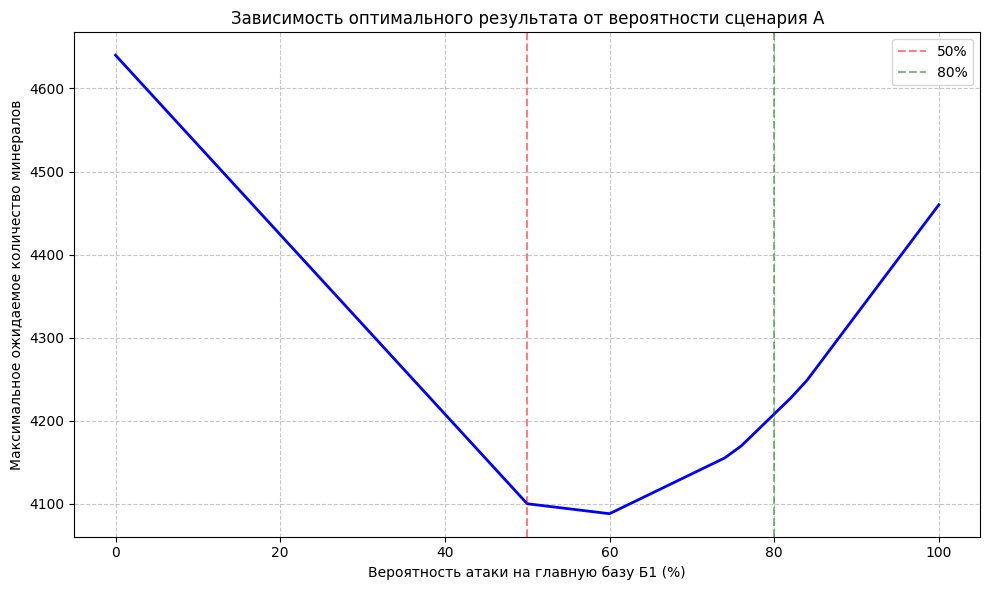

In [10]:
print("Построение графика зависимости Z_max от вероятности атаки на Б1\n")

probabilities = np.linspace(0, 1, 51)

max_minerals = []

for prob in probabilities:
    best = -np.inf
    for x1 in x1_range:
        for x2 in x2_range:
            for p in p_range:
                Z, _, _, _ = calculate_minerals_int(x1, x2, p, prob_A=prob)
                
                if Z > best:
                    best = Z
                    
    max_minerals.append(best)

plt.figure(figsize=(10, 6))
plt.plot(probabilities * 100, max_minerals, 'b-', linewidth=2)
plt.xlabel('Вероятность атаки на главную базу Б1 (%)')
plt.ylabel('Максимальное ожидаемое количество минералов')
plt.title('Зависимость оптимального результата от вероятности сценария А')

plt.grid(True, linestyle='--', alpha=0.7)
plt.axvline(x=50, color='r', linestyle='--', alpha=0.5, label='50%')
plt.axvline(x=80, color='g', linestyle='--', alpha=0.5, label='80%')

plt.legend()
plt.tight_layout()
plt.show()